# Libraries

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping


print("import done")

import done


# Load Data

In [3]:
# Define paths for the training and testing data
train_data_path = '../input/humanactivityrecognitiondataset/UCI HAR Dataset/UCI HAR Dataset/train/X_train.txt'
test_data_path = '../input/humanactivityrecognitiondataset/UCI HAR Dataset/UCI HAR Dataset/test/X_test.txt'
train_labels_path = '../input/humanactivityrecognitiondataset/UCI HAR Dataset/UCI HAR Dataset/train/y_train.txt'
test_labels_path = '../input/humanactivityrecognitiondataset/UCI HAR Dataset/UCI HAR Dataset/test/y_test.txt'

# Load the datasets
X_train = pd.read_csv(train_data_path, delim_whitespace=True, header=None)
X_test = pd.read_csv(test_data_path, delim_whitespace=True, header=None)

y_train = pd.read_csv(train_labels_path, header=None)
y_test = pd.read_csv(test_labels_path, header=None)

# Optionally, load the feature names for better understanding
features = pd.read_csv('../input/humanactivityrecognitiondataset/UCI HAR Dataset/UCI HAR Dataset/features.txt', delim_whitespace=True, header=None)

# Get the number of classes
num_classes = len(np.unique(y_train))
print(f'Number of classes: {num_classes}')

/tmp/ipykernel_24/3986527311.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_train = pd.read_csv(train_data_path, delim_whitespace=True, header=None)
/tmp/ipykernel_24/3986527311.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_test = pd.read_csv(test_data_path, delim_whitespace=True, header=None)


Number of classes: 6


/tmp/ipykernel_24/3986527311.py:15: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  features = pd.read_csv('../input/humanactivityrecognitiondataset/UCI HAR Dataset/UCI HAR Dataset/features.txt', delim_whitespace=True, header=None)


In [4]:
# Print the entire training dataset
print("X_train (Entire dataset):")
print(X_train)

# Print the entire testing dataset
print("X_test (Entire dataset):")
print(X_test)

# Print the entire training labels
print("y_train (Entire dataset):")
print(y_train)

# Print the entire testing labels
print("y_test (Entire dataset):")
print(y_test)


X_train (Entire dataset):
           0         1         2         3         4         5         6    \
0     0.288585 -0.020294 -0.132905 -0.995279 -0.983111 -0.913526 -0.995112   
1     0.278419 -0.016411 -0.123520 -0.998245 -0.975300 -0.960322 -0.998807   
2     0.279653 -0.019467 -0.113462 -0.995380 -0.967187 -0.978944 -0.996520   
3     0.279174 -0.026201 -0.123283 -0.996091 -0.983403 -0.990675 -0.997099   
4     0.276629 -0.016570 -0.115362 -0.998139 -0.980817 -0.990482 -0.998321   
...        ...       ...       ...       ...       ...       ...       ...   
7347  0.299665 -0.057193 -0.181233 -0.195387  0.039905  0.077078 -0.282301   
7348  0.273853 -0.007749 -0.147468 -0.235309  0.004816  0.059280 -0.322552   
7349  0.273387 -0.017011 -0.045022 -0.218218 -0.103822  0.274533 -0.304515   
7350  0.289654 -0.018843 -0.158281 -0.219139 -0.111412  0.268893 -0.310487   
7351  0.351503 -0.012423 -0.203867 -0.269270 -0.087212  0.177404 -0.377404   

           7         8         9    .

In [5]:
# Print the first few rows of the training dataset
print("X_train (First 5 rows):")
print(X_train.head())

# Print the first few rows of the testing dataset
print("X_test (First 5 rows):")
print(X_test.head())

# Print the first few rows of the training labels
print("y_train (First 5 rows):")
print(y_train.head())

# Print the first few rows of the testing labels
print("y_test (First 5 rows):")
print(y_test.head())

# Optionally, print feature names
print("Feature names (First 5 rows):")
print(features.head())


X_train (First 5 rows):
        0         1         2         3         4         5         6    \
0  0.288585 -0.020294 -0.132905 -0.995279 -0.983111 -0.913526 -0.995112   
1  0.278419 -0.016411 -0.123520 -0.998245 -0.975300 -0.960322 -0.998807   
2  0.279653 -0.019467 -0.113462 -0.995380 -0.967187 -0.978944 -0.996520   
3  0.279174 -0.026201 -0.123283 -0.996091 -0.983403 -0.990675 -0.997099   
4  0.276629 -0.016570 -0.115362 -0.998139 -0.980817 -0.990482 -0.998321   

        7         8         9    ...       551       552       553       554  \
0 -0.983185 -0.923527 -0.934724  ... -0.074323 -0.298676 -0.710304 -0.112754   
1 -0.974914 -0.957686 -0.943068  ...  0.158075 -0.595051 -0.861499  0.053477   
2 -0.963668 -0.977469 -0.938692  ...  0.414503 -0.390748 -0.760104 -0.118559   
3 -0.982750 -0.989302 -0.938692  ...  0.404573 -0.117290 -0.482845 -0.036788   
4 -0.979672 -0.990441 -0.942469  ...  0.087753 -0.351471 -0.699205  0.123320   

        555       556       557       558   

# Normalization

In [6]:
# # Normalize the features using MinMaxScaler (scales between 0 and 1)
# scaler = MinMaxScaler()
# X_train_normalized = scaler.fit_transform(X_train)
# X_test_normalized = scaler.transform(X_test)

# # Reshape data into 3D format (samples, time steps, features) for LSTM
# X_train_normalized = X_train_normalized.reshape((X_train_normalized.shape[0], X_train_normalized.shape[1], 1))
# X_test_normalized = X_test_normalized.reshape((X_test_normalized.shape[0], X_test_normalized.shape[1], 1))

# # One-hot encode the labels for classification
# y_train_one_hot = to_categorical(y_train)
# y_test_one_hot = to_categorical(y_test)

# Normalize the data using StandardScaler

# Adjust the labels if they are 1-based (i.e., starting from 1)
y_train = y_train - 1
y_test = y_test - 1

# Check the unique values again
print("Unique values in y_train:", np.unique(y_train))
print("Unique values in y_test:", np.unique(y_test))

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # This normalizes the data
X_test_scaled = scaler.transform(X_test)

# Reshape data to fit the CNN-LSTM model (samples, time steps, features)
X_train_scaled = X_train_scaled.reshape((X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
X_test_scaled = X_test_scaled.reshape((X_test_scaled.shape[0], X_test_scaled.shape[1], 1))

# One-hot encode the labels
y_train_one_hot = to_categorical(y_train,num_classes = 6)
y_test_one_hot = to_categorical(y_test, num_classes = 6)


Unique values in y_train: [0 1 2 3 4 5]
Unique values in y_test: [0 1 2 3 4 5]


In [7]:
print(f'Shape of y_train_one_hot: {y_train_one_hot.shape}')
print(f'Shape of y_test_one_hot: {y_test_one_hot.shape}')


Shape of y_train_one_hot: (7352, 6)
Shape of y_test_one_hot: (2947, 6)


# CNN-LSTM Building

In [9]:
# # Update the model to match the correct number of output units (7 for 7 classes)
# model = Sequential()

# # CNN layer for feature extraction
# model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train_normalized.shape[1], 1)))
# model.add(MaxPooling1D(pool_size=2))
# model.add(Dropout(0.2))

# # Another CNN layer for deeper feature extraction
# model.add(Conv1D(filters=128, kernel_size=3, activation='relu'))
# model.add(MaxPooling1D(pool_size=2))
# model.add(Dropout(0.2))

# # LSTM layer for sequence learning
# model.add(LSTM(units=100, return_sequences=False))
# model.add(Dropout(0.2))

# # Dense layers for classification
# model.add(Dense(64, activation='relu'))

# # Adjust the final layer to match the number of classes
# model.add(Dense(num_classes, activation='softmax'))  # Make sure the number of classes matches the labels

# # Compile the model
# model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Build the model
model = Sequential()

# CNN layer for feature extraction
model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train_scaled.shape[1], 1)))
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.2))

# Another CNN layer for deeper feature extraction
model.add(Conv1D(filters=128, kernel_size=3, activation='relu'))
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.2))

# LSTM layer for sequence learning
model.add(LSTM(units=100, return_sequences=False))
model.add(Dropout(0.2))

# Dense layers for classification
model.add(Dense(64, activation='relu'))

# Output layer with 6 classes
model.add(Dense(6, activation='softmax'))  # 6 classes
model.summary()

# Compile the model
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])


/opt/conda/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 559, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 279, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 279, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 277, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 138, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 138, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100)            │        91,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,414 (482.09 KB)

 Trainable params: 123,414 (482.09 KB)

 Non-trainable params: 0 (0.00 B)

# Training and Testing Model

In [10]:
# EarlyStopping callback to stop training when validation loss stops improving
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model with EarlyStopping

history = model.fit(
    X_train_scaled, y_train_one_hot,
    epochs=50,  # Start with a large number of epochs
    batch_size=64,
    validation_data=(X_test_scaled, y_test_one_hot),
    callbacks=[early_stopping]
)

# Evaluate the model on test data
y_pred = model.predict(X_test_scaled)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_one_hot, axis=1)


Epoch 1/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 32s 249ms/step - accuracy: 0.3660 - loss: 1.2664 - val_accuracy: 0.4656 - val_loss: 1.0187
Epoch 2/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 28s 243ms/step - accuracy: 0.4888 - loss: 0.9862 - val_accuracy: 0.5137 - val_loss: 0.9901
Epoch 3/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 28s 244ms/step - accuracy: 0.5447 - loss: 0.9103 - val_accuracy: 0.5976 - val_loss: 0.8438
Epoch 4/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 28s 243ms/step - accuracy: 0.5979 - loss: 0.8265 - val_accuracy: 0.6298 - val_loss: 0.8200
Epoch 5/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 28s 242ms/step - accuracy: 0.6827 - loss: 0.7103 - val_accuracy: 0.7255 - val_loss: 0.6138
Epoch 6/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 28s 241ms/step - accuracy: 0.7386 - loss: 0.5593 - val_accuracy: 0.7513 - val_loss: 0.5110
Epoch 7/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 28s 246ms/step - accuracy: 0.7861 - loss: 0.4448 - val_accuracy: 0.7720 - val_loss: 0.4475
Epoch 8/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 28s 244ms/step - accuracy: 0.7837 - loss: 0

# Evaluation

In [11]:
# Accuracy
accuracy = accuracy_score(y_true, y_pred_classes)
print(f'Accuracy: {accuracy:.4f}')

# Precision
precision = precision_score(y_true, y_pred_classes, average='weighted')
print(f'Precision: {precision:.4f}')

# Recall
recall = recall_score(y_true, y_pred_classes, average='weighted')
print(f'Recall: {recall:.4f}')

# F1 Score
f1 = f1_score(y_true, y_pred_classes, average='weighted')
print(f'F1 Score: {f1:.4f}')


Accuracy: 0.9067
Precision: 0.9079
Recall: 0.9067
F1 Score: 0.9059


# Plotting

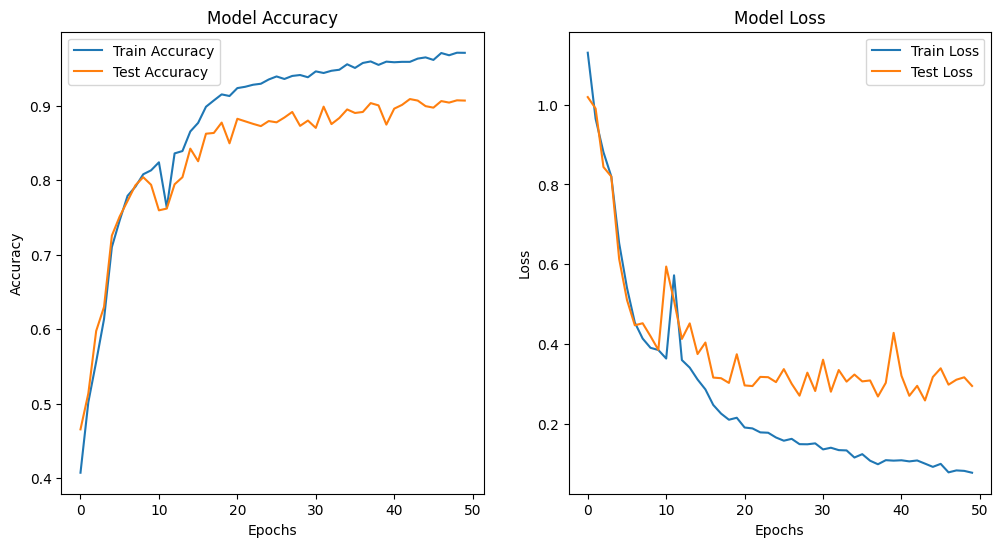

In [12]:
# Plot training & validation accuracy
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()
